In [1]:
from recommender_system.data.load import load_data
from recommender_system.data.transform import transform_reviews

df = load_data('../data/australian_user_reviews.json.gz')
reviews = transform_reviews(df)

reviews = reviews.astype({'recommend': 'int'})
reviews.head()

,user_id,posted,item_id,recommend
0,76561197970982479,"Posted November 5, 2011.",1250,1
1,76561197970982479,"Posted July 15, 2011.",22200,1
2,76561197970982479,"Posted April 21, 2011.",43110,1
3,js41637,"Posted June 24, 2014.",251610,1
4,js41637,"Posted September 8, 2013.",227300,1


In [2]:
from recommender_system.features.interactions import df2interact_mat

interactions, item_to_idx = df2interact_mat(reviews, 'user_id', 'item_id', 'recommend')


In [12]:
from recommender_system.models.matrixfactorization import MatrixFactorization

model = MatrixFactorization(n_factors=25)
model.fit(interactions, n_epochs=50, learning_rate=0.1, regularization=0.1)
#predictions = model.predict()

Epoch 1/50, RMSE: 0.9623
Epoch 2/50, RMSE: 0.9334
Epoch 3/50, RMSE: 0.8532
Epoch 4/50, RMSE: 0.6920
Epoch 5/50, RMSE: 0.5427
Epoch 6/50, RMSE: 0.4456
Epoch 7/50, RMSE: 0.3815
Epoch 8/50, RMSE: 0.3364
Epoch 9/50, RMSE: 0.3033
Epoch 10/50, RMSE: 0.2782
Epoch 11/50, RMSE: 0.2588
Epoch 12/50, RMSE: 0.2435
Epoch 13/50, RMSE: 0.2313
Epoch 14/50, RMSE: 0.2215
Epoch 15/50, RMSE: 0.2135
Epoch 16/50, RMSE: 0.2068
Epoch 17/50, RMSE: 0.2014
Epoch 18/50, RMSE: 0.1968
Epoch 19/50, RMSE: 0.1929
Epoch 20/50, RMSE: 0.1896
Epoch 21/50, RMSE: 0.1868
Epoch 22/50, RMSE: 0.1844
Epoch 23/50, RMSE: 0.1823
Epoch 24/50, RMSE: 0.1805
Epoch 25/50, RMSE: 0.1789
Epoch 26/50, RMSE: 0.1775
Epoch 27/50, RMSE: 0.1763
Epoch 28/50, RMSE: 0.1752
Epoch 29/50, RMSE: 0.1742
Epoch 30/50, RMSE: 0.1734
Epoch 31/50, RMSE: 0.1726
Epoch 32/50, RMSE: 0.1719
Epoch 33/50, RMSE: 0.1713
Epoch 34/50, RMSE: 0.1707
Epoch 35/50, RMSE: 0.1702
Epoch 36/50, RMSE: 0.1697
Epoch 37/50, RMSE: 0.1693
Epoch 38/50, RMSE: 0.1689
Epoch 39/50, RMSE: 0.

In [4]:
games = load_data("../data/steam_games.json.gz")
games = games.rename({'id': 'item_id'}, axis=1)
games = games[['item_id', 'app_name']]

(3682, 3682)
(3682, 25)
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   item_id  30 non-null     str    
 1   scores   30 non-null     float64
dtypes: float64(1), str(1)
memory usage: 612.0 bytes
None


,item_id,scores,app_name
0,298630,0.816390,The Escapists
1,10180,0.811101,Call of Duty®: Modern Warfare® 2
2,440,0.808869,Team Fortress 2
3,267381,0.807682,PAYDAY 2: A Merry Payday Christmas Soundtrack
4,225540,0.807429,Just Cause™ 3
5,24720,0.805753,SPORE™ Galactic Adventures
6,312280,0.802562,Simply Chess
7,384021,0.800969,PAYDAY 2: Gage Ninja Pack
8,249570,0.798803,The Castle Doctrine
9,251630,0.797154,The Impossible Game


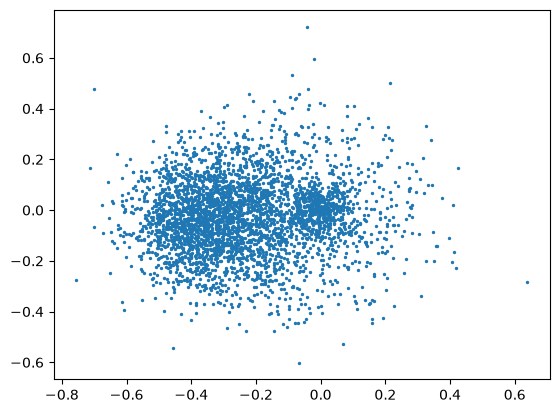

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
from recommender_system.models.collaborative_filtering import get_similar_items
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

similarities = cosine_similarity(model.V)
print(similarities.shape)
#plt.imshow(similarities, cmap='hot', interpolation='nearest')
#plt.colorbar()
plt.scatter(model.V[:, 0], model.V[:, 1], s=2)
print(model.V.shape)

recommendations = get_similar_items('730', csr_matrix(similarities), item_to_idx, k=30)
print(recommendations.info())
recommendations = recommendations.merge(games, on='item_id', how='left')
recommendations.head(10)


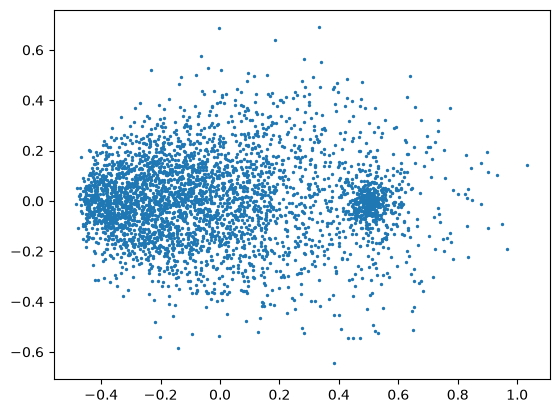

In [15]:
from sklearn.decomposition import PCA

V_2d = PCA(n_components=2).fit_transform(model.V)

plt.scatter(V_2d[:, 0], V_2d[:, 1], s=2)